# Projection figures - BNA, 2035 and 2050

Five figures for the projection chapter of the thesis, numbered as in the manuscript. They reuse the charter of
`analyse_resultats.ipynb` (chapter-5 figures): same fonts, same 16 cm print width, same
colour palette.

| Figure | Content |
|---|---|
| 11 | Population vs households, indexed to 100 in 2024, regional, 2024-2050 |
| 12 | Electricity access rate (Source A + Source B) by cluster, 2024 / 2035 / 2050, both trajectories |
| 26 | Annual cost of the seven projection runs, investment / maintenance / resources, grouped by horizon |
| 27 | Regional PV_UTILITY installed capacity in 2025 / 2035 / 2050, one line per scenario |
| 28 | Cost and emission trajectories, 2025 / 2035 / 2050, from the shared 2025 anchor |

**Display labels.** The scenario internally named `no_transition` is labelled **Diesel only** on the
figures. This is a caption change only: no folder, path, case-study name or dictionary key is
renamed anywhere. The mapping lives in `DISPLAY` and is applied at draw time, nowhere else.

**Data sources**

* `bolivia-energy-data/projections/output/menages_projetes.csv` - projected population and households
* `bolivia-energy-data/exctraction of data/output/CSV_final.csv` - 2001/2012/2024 census, needed to
  rebuild the *annual* household path (the deliverable CSV only carries the 2024/2035/2050 anchors)
* `bolivia-energy-data/projections/output/split_abc_projete.csv` - households by source A/B/C
* `bolivia-energy-data/analyse data ramp/2050/output_energyscope_2050/vintage_registry.csv` - the
  2035 capacity tranches chained into 2050, with their own vintage `c_inv`
* `EnergyScope_BO_nord_amazonia/case_studies/C1_C2_C3_C4_C5/<run>/outputs/` - solved runs

**Cost metric**: reconstructed, never LP raw. See section 3.

---
**Units**: costs in M-euro/year . capacity in MW . access in % of households

In [1]:
import math
import sys
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Same print charter as the chapter-5 figures of analyse_resultats.ipynb: compact 16 cm
# figures, no top/right spines. Type is sized for a 16 cm insert in an A4 page, so a point
# here is a printed point: axis labels, tick labels and legends sit in the 9.5-10.5 pt band,
# inline value labels one step below at 8.5 pt so that they read as annotation.
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10, 'axes.titlesize': 10.5, 'axes.labelsize': 10.5,
    'legend.fontsize': 9.5, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CM = 1 / 2.54

def find_repo_root():
    """Repository root, whether this notebook runs from scripts/ or from the root."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'esmc').is_dir() and (candidate / 'case_studies').is_dir():
            return candidate
    raise RuntimeError(f'repository root not found above {here}')


ES_ROOT = find_repo_root()
if str(ES_ROOT) not in sys.path:
    sys.path.insert(0, str(ES_ROOT))
from paths import BOLIVIA_DATA as BOLIVIA

CS_ROOT = ES_ROOT / 'case_studies' / 'C1_C2_C3_C4_C5'
PROJ_OUT = BOLIVIA / 'projections' / 'output'
RAMP_2050 = BOLIVIA / 'analyse data ramp' / '2050' / 'output_energyscope_2050'


REGIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
EPS = 1e-6

# Scenario palette.
# The two access calendars keep their chapter-5 values, "supply transition" blue and
# "universal access" amber, so both chapters read as one document. The frozen supply
# no longer carries the chapter-5 "current system" green: in the emissions panel it is
# the curve that climbs to 380.7 ktCO2eq, and green reads as clean in every other
# figure of the document. It is drawn in a fuel brown-red instead.
SCEN_COLORS = {
    'No transition':  '#A8453A',
    'Late access':    '#5A9AE3',
    'Early access':   '#D9A441',
    'Early access\n+ Brazilian import': '#8B6DAE',
}
# Cost / demography colours, identical to analyse_resultats.ipynb
COST_COLORS = {'C_inv': '#5A9AE3', 'C_maint': '#A384E4', 'C_op': '#C2704D'}
COST_LABELS = {'C_inv': 'Investment', 'C_maint': 'Maintenance', 'C_op': 'Resources'}
POP_COLOR, HH_COLOR = '#5A9AE3', '#D9A441'
NEUTRAL = '#9AA5B1'

# Caption text only. The keys below are the internal scenario labels used everywhere
# in this notebook and in the registry; none of them is renamed. Only the strings that
# end up drawn on a figure go through DISPLAY.
DISPLAY = {
    'No transition':                     'Diesel only',
    'Late access':                       'Late access',
    'Early access':                      'Early access',
    'Early access\n+ Brazilian import':  'Early access with import',
}
ANCHOR_LABEL = 'Current system (2025)'
# Same four labels, line-wrapped for the axis of Figure 3 where the tick spacing is tight:
# seven bars share the 16 cm width, i.e. about 1.9 cm per label, and at 9.5 pt that is
# roughly seven characters per line.
DISPLAY_TICK = {k: textwrap.fill(v, 7) for k, v in DISPLAY.items()}

for p in (PROJ_OUT, RAMP_2050, CS_ROOT):
    assert p.exists(), (f'missing path: {p}\n'
                        'bolivia-energy-data is expected next to this repository')
print(f'EnergyScope runs : {CS_ROOT.relative_to(ES_ROOT)}')
print(f'projection data  : bolivia-energy-data/{PROJ_OUT.relative_to(BOLIVIA)}')


EnergyScope runs : case_studies\C1_C2_C3_C4_C5
projection data  : bolivia-energy-data/projections\output


---
## 1. Population and households diverge  [manuscript figure 11]

`menages_projetes.csv` only carries the 2024 / 2035 / 2050 anchors, so the annual path is
rebuilt here with the exact rule of `projections/02_population_2035_2050.ipynb`, step 11:

* population: constant log growth rate inside each segment
  (`taux_pop_2435 = 100 ln(P_2035/P_2024)/11`, `taux_pop_3550 = 100 ln(P_2050/P_2035)/15`) -
  this is the population path the household model itself assumes, not an interpolation added here;
* households: annual chaining `hh(t) = hh(t-1) * (1 + (taux_pop(t) + ecart(t))/100)` with
  `ecart(t) = ecart_1224[group] * 0.642^((t-2024)/12)`, the single regional decay factor of step 11,
  and the two starting gaps estimated on the 2012-2024 censuses (urban / rest).

The rebuilt 2035 and 2050 values are asserted against the deliverable CSV, so the curve is
guaranteed to pass through the published anchors.

In [2]:
KEYS = ['DEPARTAMENTO', 'PROVINCIA', 'MUNICIPIO/TIOC']
POP_BLOCK = 'N\u00daMERO DE PERSONAS POR FUENTE DE ELECTRICIDAD'
HH_BLOCK = 'N\u00daMERO DE VIVIENDAS POR FUENTE DE ELECTRICIDAD'
HH_SUBCOL = {2001: 'Electricidad total', 2012: 'Total', 2024: 'Total'}
URBAN = ['Cobija', 'Riberalta', 'Guayaramer\u00edn']

raw = pd.read_csv(BOLIVIA / 'exctraction of data' / 'output' / 'CSV_final.csv', encoding='utf-8')
muni = raw[raw['MUNICIPIO/TIOC'].notna() & (raw['MUNICIPIO/TIOC'].astype(str).str.strip() != '')].copy()
assert len(muni) == 21, len(muni)

census = muni[KEYS].copy().reset_index(drop=True)
for y in (2001, 2012, 2024):
    census[f'pop_{y}'] = muni[f'{POP_BLOCK} | {y} | Total'].astype(float).values
    census[f'hh_{y}'] = muni[f'{HH_BLOCK} | {y} | {HH_SUBCOL[y]}'].astype(float).values
census['group'] = np.where(census['MUNICIPIO/TIOC'].isin(URBAN), 'urban', 'rest')

# Regional decay factor of the decohabitation gap (step 10.1 / 11)
region = raw[raw['DEPARTAMENTO'] == 'Amazon\u00eda Norte']
pop_reg = {y: float(region[f'{POP_BLOCK} | {y} | Total'].iloc[0]) for y in (2001, 2012, 2024)}
hh_reg = {y: float(region[f'{HH_BLOCK} | {y} | {HH_SUBCOL[y]}'].iloc[0]) for y in (2001, 2012, 2024)}
gap_0112 = 100 * math.log(hh_reg[2012] / hh_reg[2001]) / 11 - 100 * math.log(pop_reg[2012] / pop_reg[2001]) / 11
gap_1224 = 100 * math.log(hh_reg[2024] / hh_reg[2012]) / 12 - 100 * math.log(pop_reg[2024] / pop_reg[2012]) / 12
decay = gap_1224 / gap_0112

# Starting gap per group, estimated on 2012-2024
grp = census.groupby('group')[['pop_2012', 'pop_2024', 'hh_2012', 'hh_2024']].sum()
gap_start = {g: (100 * math.log(r['hh_2024'] / r['hh_2012']) / 12
                 - 100 * math.log(r['pop_2024'] / r['pop_2012']) / 12) for g, r in grp.iterrows()}

print(f'gap 2001-2012 = {gap_0112:.3f} pts/yr   gap 2012-2024 = {gap_1224:.3f} pts/yr   decay = {decay:.3f}')
print(f'starting gap  : urban {gap_start["urban"]:.3f} pts/yr   rest {gap_start["rest"]:.3f} pts/yr')

# -- Anchors from the deliverable ------------------------------------------
mp = pd.read_csv(PROJ_OUT / 'menages_projetes.csv')
mp_idx = mp.set_index(['departamento', 'provincia', 'municipio'])
census_idx = census.set_index(KEYS)
order = census_idx.index
pop_2024 = census_idx['pop_2024'].values
hh_2024 = census_idx['hh_2024'].values.astype(float)
pop_2035 = mp_idx.loc[order, 'pop_2035'].values
pop_2050 = mp_idx.loc[order, 'pop_2050'].values
assert np.allclose(pop_2024, mp_idx.loc[order, 'pop_2024'].values)
assert np.allclose(hh_2024, mp_idx.loc[order, 'hh_2024'].values)

rate_2435 = 100 * np.log(pop_2035 / pop_2024) / 11
rate_3550 = 100 * np.log(pop_2050 / pop_2035) / 15
group_arr = census_idx['group'].values

YEARS = list(range(2024, 2051))
pop_path, hh_path = {2024: pop_2024.copy()}, {2024: hh_2024.copy()}
hh_run = hh_2024.copy()
for t in range(2025, 2051):
    rate_t = np.where(t <= 2035, rate_2435, rate_3550)
    gap_t = np.array([gap_start[g] * decay ** ((t - 2024) / 12) for g in group_arr])
    hh_run = hh_run * (1 + (rate_t + gap_t) / 100)
    hh_path[t] = hh_run.copy()
    pop_path[t] = np.where(t <= 2035,
                           pop_2024 * np.exp(rate_2435 / 100 * (t - 2024)),
                           pop_2035 * np.exp(rate_3550 / 100 * (t - 2035)))

# The rebuilt path must land exactly on the published anchors
for t in (2035, 2050):
    assert np.allclose(hh_path[t], mp_idx.loc[order, f'hh_{t}'].values), f'household anchor {t} mismatch'
    assert np.allclose(pop_path[t], mp_idx.loc[order, f'pop_{t}'].values), f'population anchor {t} mismatch'

pop_series = pd.Series({t: pop_path[t].sum() for t in YEARS})
hh_series = pd.Series({t: hh_path[t].sum() for t in YEARS})
pop_index = pop_series / pop_series[2024] * 100
hh_index = hh_series / hh_series[2024] * 100

print('\nRegional trajectory (levels):')
print(pd.DataFrame({'population': pop_series, 'households': hh_series,
                    'household size': pop_series / hh_series}).loc[[2024, 2035, 2050]].round(3).to_string())
print('\nIndexed to 100 in 2024:')
print(pd.DataFrame({'population': pop_index, 'households': hh_index}).loc[[2024, 2035, 2050]].round(2).to_string())

gap 2001-2012 = 1.687 pts/yr   gap 2012-2024 = 1.083 pts/yr   decay = 0.642
starting gap  : urban 0.934 pts/yr   rest 1.373 pts/yr

Regional trajectory (levels):
      population  households  household size
2024  317517.000   84209.000           3.771
2035  349534.430  101782.968           3.434
2050  381164.675  120198.990           3.171

Indexed to 100 in 2024:
      population  households
2024      100.00      100.00
2035      110.08      120.87
2050      120.05      142.74


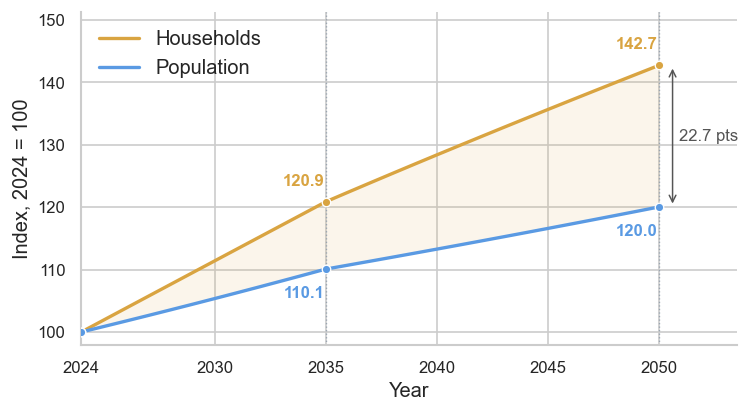

2050: population index 120.0, households index 142.7  (381,165 inhabitants, 120,199 households)


In [3]:
fig, ax = plt.subplots(figsize=(16.25 * CM, 9 * CM))

ax.fill_between(YEARS, pop_index.values, hh_index.values, color=HH_COLOR, alpha=0.10, lw=0)
ax.plot(YEARS, hh_index.values, color=HH_COLOR, lw=2.0, label='Households', zorder=3)
ax.plot(YEARS, pop_index.values, color=POP_COLOR, lw=2.0, label='Population', zorder=3)

for t in (2035, 2050):
    ax.axvline(t, color=NEUTRAL, lw=0.8, ls=':', zorder=1)
ax.scatter([2024, 2035, 2050], [hh_index[t] for t in (2024, 2035, 2050)],
           s=26, color=HH_COLOR, edgecolor='white', linewidth=0.8, zorder=4)
ax.scatter([2024, 2035, 2050], [pop_index[t] for t in (2024, 2035, 2050)],
           s=26, color=POP_COLOR, edgecolor='white', linewidth=0.8, zorder=4)

for t, ha, dx in ((2035, 'right', -1.0), (2050, 'right', -1.0)):
    ax.annotate(f'{hh_index[t]:.1f}', (t, hh_index[t]), xytext=(dx, 8), textcoords='offset points',
                ha=ha, va='bottom', fontsize=10, fontweight='bold', color=HH_COLOR)
    ax.annotate(f'{pop_index[t]:.1f}', (t, pop_index[t]), xytext=(dx, -10), textcoords='offset points',
                ha=ha, va='top', fontsize=10, fontweight='bold', color=POP_COLOR)

# Gap arrow at 2050, the result the chapter turns on
ax.annotate('', xy=(2050.6, hh_index[2050]), xytext=(2050.6, pop_index[2050]),
            arrowprops=dict(arrowstyle='<->', color='#555555', lw=0.9))
ax.annotate(f'{hh_index[2050] - pop_index[2050]:.1f} pts', (2050.9, (hh_index[2050] + pop_index[2050]) / 2),
            ha='left', va='center', fontsize=10, color='#555555')

ax.set_xlim(2024, 2053.5)
ax.set_ylim(98, max(hh_index) * 1.06)
ax.set_xticks([2024, 2030, 2035, 2040, 2045, 2050])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Index, 2024 = 100', fontsize=12)
ax.legend(loc='upper left', frameon=False, fontsize=12)

plt.tight_layout()
plt.show()
print(f'2050: population index {pop_index[2050]:.1f}, households index {hh_index[2050]:.1f}'
      f'  ({pop_series[2050]:,.0f} inhabitants, {hh_series[2050]:,.0f} households)')

---
## 2. Access rate by cluster under the two trajectories  [manuscript figure 12]

Access = share of households in **Source A + Source B** (a household on a standalone system has
access, it simply has no line). Universal access therefore means an empty Source C, not a Source A
covering every household.

2024 is shared by the two trajectories, and so is 2050 (both reach 100 %). Only 2035 differs.

In [4]:
split = pd.read_csv(PROJ_OUT / 'split_abc_projete.csv')

by_cluster = split.groupby(['trajectoire', 'annee', 'cluster'])[['hh_total', 'hh_A', 'hh_B', 'hh_C']].sum()
by_cluster['access_pct'] = 100 * (by_cluster['hh_A'] + by_cluster['hh_B']) / by_cluster['hh_total']
by_region = split.groupby(['trajectoire', 'annee'])[['hh_total', 'hh_A', 'hh_B', 'hh_C']].sum()
by_region['access_pct'] = 100 * (by_region['hh_A'] + by_region['hh_B']) / by_region['hh_total']

# 2024 and 2050 must be identical across the two trajectories - the comparison rests on it
for yr in (2024, 2050):
    a = by_cluster.xs(('acces_2035', yr), level=('trajectoire', 'annee'))['access_pct']
    b = by_cluster.xs(('acces_2050', yr), level=('trajectoire', 'annee'))['access_pct']
    assert np.allclose(a.values, b.values), f'{yr}: the two trajectories disagree'

GROUPS = ['C1', 'C2', 'C3', 'C4', 'C5', 'Region']


def access_of(traj, year):
    s = by_cluster.xs((traj, year), level=('trajectoire', 'annee'))['access_pct'].reindex(REGIONS)
    return np.append(s.values, by_region.loc[(traj, year), 'access_pct'])


BARS = [
    ('2024\nobserved',          access_of('acces_2035', 2024), NEUTRAL,   None),
    ('2035\naccess in 2035',    access_of('acces_2035', 2035), '#D9A441', None),
    ('2035\naccess in 2050',    access_of('acces_2050', 2035), '#5A9AE3', None),
    ('2050\nboth trajectories', access_of('acces_2035', 2050), '#5B9E5B', None),
]

print(pd.DataFrame({lab.replace('\n', ' '): vals for lab, vals, _, _ in BARS}, index=GROUPS).round(2).to_string())

        2024 observed  2035 access in 2035  2035 access in 2050  2050 both trajectories
C1              77.74                100.0                89.03                   100.0
C2              68.45                100.0                86.56                   100.0
C3              89.83                100.0                94.83                   100.0
C4              74.66                100.0                89.43                   100.0
C5              97.46                100.0                99.28                   100.0
Region          86.48                100.0                93.74                   100.0


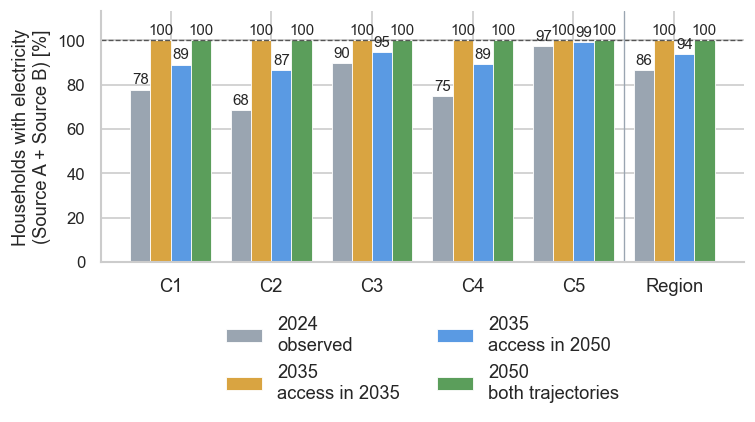

In [5]:
fig, ax = plt.subplots(figsize=(16.25 * CM, 9.5 * CM))

x = np.arange(len(GROUPS))
w = 0.20
for i, (lab, vals, col, _) in enumerate(BARS):
    dx = (i - (len(BARS) - 1) / 2) * w
    ax.bar(x + dx, vals, w, color=col, edgecolor='white', linewidth=0.5, label=lab)
    for xi, v in zip(x + dx, vals):
        ax.text(xi, v + 1.2, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

ax.axhline(100, color='#555555', lw=0.8, ls='--', zorder=1)
ax.axvline(len(REGIONS) - 0.5, color=NEUTRAL, lw=0.8, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(GROUPS, fontsize=11)
ax.set_ylim(0, 113)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_ylabel('Households with electricity\n(Source A + Source B) [%]', fontsize=11)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=11, ncol=2, frameon=False)

plt.tight_layout()
plt.show()


---
## 3. Annual cost of the seven projection runs - reconstructed, not LP raw  [manuscript figure 26]

The LP's own `C_inv` excludes `f_min` capacity from the investment cost
(`C_inv[c,j] = c_inv[c,j] * (F[c,j] - f_min[c,j])`), so at 2050 the capacity chained forward from
the 2035 solve is implicitly free. The published cost is therefore the **reconstructed** one: every
`chained_to_2050` tranche of `vintage_registry.csv` is re-invoiced at its **own vintage-year**
`c_inv`, annualised with `tau = i(1+i)^L / ((1+i)^L - 1)`, `i = 0.1`, and added to the investment
line. `retired_at_2050` tranches are never re-added.

This is the same computation as `bolivia-energy-data/analyse data ramp/2050/cost_reconstruction.ipynb`,
redone here from the raw `Cost_breakdown.csv` + registry so that the bars are built from the same
numbers they are labelled with. Every bar is asserted against the published reconstructed total.

The 2035 runs carry no adjustment by construction (2035 is the first horizon capacity is chained
*into*, not out of), so their bars are the plain LP breakdown.

In [6]:
I_RATE = 0.1

RUNS = [
    # (display label, horizon, scenario key in the registry, case-study folder, Data/<year>/<folder>)
    ('No transition',  2035, 'no_transition',       'norte_amazonia_no_transition_2035',       'no_transition'),
    ('Late access',    2035, 'late_access',         'norte_amazonia_late_access_2035',         'late_access'),
    ('Early access',   2035, 'early_access',        'norte_amazonia_early_access_2035',        'early_access'),
    ('No transition',  2050, 'no_transition',       'norte_amazonia_no_transition_2050',       'no_transition'),
    ('Late access',    2050, 'late_access',         'norte_amazonia_late_access_2050',         'late_access'),
    ('Early access',   2050, 'early_access',        'norte_amazonia_early_access_2050',        'early_access'),
    ('Early access\n+ Brazilian import', 2050, 'early_access_brazil',
     'norte_amazonia_early_access_brazil_2050', 'early_access_brazil'),
]

# Published reconstructed totals, from cost_reconstruction.ipynb - used as an assertion target
PUBLISHED = {
    ('No transition', 2035): 89.451, ('Late access', 2035): 44.058, ('Early access', 2035): 49.290,
    ('No transition', 2050): 123.411, ('Late access', 2050): 52.566, ('Early access', 2050): 52.962,
    ('Early access\n+ Brazilian import', 2050): 44.226,
}

registry = pd.read_csv(RAMP_2050 / 'vintage_registry.csv', sep=';')

cost_rows = []
for label, year, key, case_study, data_folder in RUNS:
    out_dir = CS_ROOT / case_study / 'outputs'

    solve_info = pd.read_csv(out_dir / 'Solve_info.csv', sep=r'\t;\t', header=None,
                             index_col=0, engine='python')
    status = int(float(solve_info.loc['solve_result_num', 1]))
    assert status == 0, f'{case_study}: solve_result_num={status} - refusing to use this run'

    lp_total = pd.read_csv(out_dir / 'TotalCost.csv', sep=';', index_col=0).iloc[0, 0]
    breakdown = pd.read_csv(out_dir / 'Cost_breakdown.csv', sep=';', index_col=0).fillna(0.0)

    catalog = pd.read_csv(ES_ROOT / 'Data' / str(year) / data_folder / '02_REF_REGION' / 'Technologies.csv',
                          sep=';', skiprows=[1])
    catalog['Technologies param'] = catalog['Technologies param'].str.strip()
    catalog = catalog.set_index('Technologies param')

    adjustment = 0.0
    if year == 2050:
        chained = registry[(registry['scenario'] == key) & (registry['status'] == 'chained_to_2050')]
        for _, r in chained.iterrows():
            tech = r['technology']
            if tech not in catalog.index:
                continue
            lifetime = float(catalog.loc[tech, 'lifetime'])
            tau = I_RATE * (1 + I_RATE) ** lifetime / ((1 + I_RATE) ** lifetime - 1)
            adjustment += r['capacity_GW'] * r['c_inv'] * tau

    c_inv_lp = float(breakdown['C_inv'].sum())
    c_maint = float(breakdown['C_maint'].sum())
    c_op = float(breakdown['C_op'].sum())
    reconstructed = c_inv_lp + adjustment + c_maint + c_op

    # The bar must sum to the published reconstructed total (tolerance covers the
    # Cost_breakdown-vs-TotalCost CSV rounding residual plus the 3-decimal published figure)
    target = PUBLISHED[(label, year)]
    assert abs(reconstructed - target) < 1e-3, \
        f'{label} {year}: bar sums to {reconstructed:.4f}, published total is {target:.3f}'

    cost_rows.append(dict(label=label, year=year, C_inv_lp=c_inv_lp, adjustment=adjustment,
                          C_maint=c_maint, C_op=c_op, reconstructed=reconstructed,
                          lp_raw=lp_total))

costs = pd.DataFrame(cost_rows)
print('All seven bars sum to the published reconstructed total (max deviation < 0.001 M-euro/yr).\n')
print(costs.assign(label=lambda d: d['label'].str.replace('\n', ' ')).round(3).to_string(index=False))

All seven bars sum to the published reconstructed total (max deviation < 0.001 M-euro/yr).

                          label  year  C_inv_lp  adjustment  C_maint    C_op  reconstructed  lp_raw
                  No transition  2035     3.177       0.000    2.002  84.272         89.451  89.451
                    Late access  2035    28.933       0.000    7.679   7.447         44.058  44.058
                   Early access  2035    32.586       0.000    8.555   8.150         49.290  49.290
                  No transition  2050     3.977       2.718    2.096 114.619        123.411 120.692
                    Late access  2050    18.951      15.470    9.964   8.181         52.566  37.096
                   Early access  2050    17.358      17.433    9.946   8.225         52.962  35.529
Early access + Brazilian import  2050     5.834      17.433    8.127  12.832         44.226  26.793


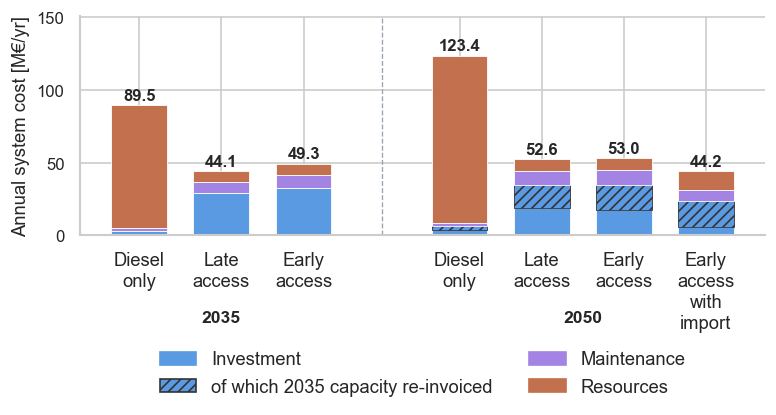


2050 gap, reconstructed : early access 52.962 - late access 52.566 = +0.396 M€/yr
2050 gap, LP raw        : early access 35.529 - late access 37.096 = -1.567 M€/yr


In [7]:
fig, ax = plt.subplots(figsize=(16.7 * CM, 10.5 * CM))

# Two horizon groups, separated by a gap
pos, ticks, tick_labels = [], [], []
p = 0.0
for i, (_, r) in enumerate(costs.iterrows()):
    if i > 0 and r['year'] != costs.iloc[i - 1]['year']:
        p += 0.9
    pos.append(p)
    ticks.append(p)
    tick_labels.append(DISPLAY_TICK[r['label']])
    p += 1.0
pos = np.array(pos)

w = 0.68
for xi, (_, r) in zip(pos, costs.iterrows()):
    bottom = 0.0
    ax.bar(xi, r['C_inv_lp'], w, bottom=bottom, color=COST_COLORS['C_inv'],
           edgecolor='white', linewidth=0.5)
    bottom += r['C_inv_lp']
    if r['adjustment'] > EPS:
        ax.bar(xi, r['adjustment'], w, bottom=bottom, color=COST_COLORS['C_inv'],
               edgecolor='#333333', linewidth=0.5, hatch='////')
        bottom += r['adjustment']
    ax.bar(xi, r['C_maint'], w, bottom=bottom, color=COST_COLORS['C_maint'],
           edgecolor='white', linewidth=0.5)
    bottom += r['C_maint']
    ax.bar(xi, r['C_op'], w, bottom=bottom, color=COST_COLORS['C_op'],
           edgecolor='white', linewidth=0.5)
    bottom += r['C_op']
    ax.text(xi, bottom + 1.6, f'{bottom:.1f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ymax = costs['reconstructed'].max() * 1.22
ax.set_ylim(0, ymax)
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=11)
ax.set_ylabel('Annual system cost [M\u20ac/yr]', fontsize=11)

# Horizon brackets under the axis
sep = (pos[2] + pos[3]) / 2
ax.axvline(sep, color=NEUTRAL, lw=0.8, ls='--', zorder=1)
for lo, hi, lab in ((pos[0], pos[2], '2035'), (pos[3], pos[6], '2050')):
    ax.annotate(lab, ((lo + hi) / 2, -0.34), xycoords=('data', 'axes fraction'),
                ha='center', va='top', fontsize=10.5, fontweight='bold')

handles = [mpatches.Patch(color=COST_COLORS['C_inv'], label=COST_LABELS['C_inv']),
           mpatches.Patch(facecolor=COST_COLORS['C_inv'], edgecolor='#333333', hatch='////',
                          label='of which 2035 capacity re-invoiced'),
           mpatches.Patch(color=COST_COLORS['C_maint'], label=COST_LABELS['C_maint']),
           mpatches.Patch(color=COST_COLORS['C_op'], label=COST_LABELS['C_op'])]
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.45), fontsize=11, ncol=2, frameon=False)

plt.tight_layout()
plt.show()

c50 = costs[costs['year'] == 2050].set_index('label')
print(f"\n2050 gap, reconstructed : early access {c50.loc['Early access', 'reconstructed']:.3f} - "
      f"late access {c50.loc['Late access', 'reconstructed']:.3f} = "
      f"{c50.loc['Early access', 'reconstructed'] - c50.loc['Late access', 'reconstructed']:+.3f} M\u20ac/yr")
print(f"2050 gap, LP raw        : early access {c50.loc['Early access', 'lp_raw']:.3f} - "
      f"late access {c50.loc['Late access', 'lp_raw']:.3f} = "
      f"{c50.loc['Early access', 'lp_raw'] - c50.loc['Late access', 'lp_raw']:+.3f} M\u20ac/yr")

---
## 4. Regional PV_UTILITY capacity  [manuscript figure 27]

Installed capacity summed over the five clusters, read from `Assets.csv` (`F`, in GW, converted
to MW). The 2025 point is the current system (`norte_amazonia_reality_2025`), which every
projection scenario starts from: the brownfield rule charges no capital on the fleet that already
exists, so the two trajectories and the frozen scenario share it.

`Early access + Brazilian import` has no 2035 run of its own - it is chained from the
`early_access` 2035 solve (`vintage_registry.csv`, `source_2035_scenario`), so it legitimately
passes through the same 2035 point.

In [8]:
PV_RUNS = {
    'No transition':  {2025: 'norte_amazonia_reality_2025', 2035: 'norte_amazonia_no_transition_2035',
                       2050: 'norte_amazonia_no_transition_2050'},
    'Late access':    {2025: 'norte_amazonia_reality_2025', 2035: 'norte_amazonia_late_access_2035',
                       2050: 'norte_amazonia_late_access_2050'},
    'Early access':   {2025: 'norte_amazonia_reality_2025', 2035: 'norte_amazonia_early_access_2035',
                       2050: 'norte_amazonia_early_access_2050'},
    'Early access\n+ Brazilian import': {2025: 'norte_amazonia_reality_2025',
                                         2035: 'norte_amazonia_early_access_2035',
                                         2050: 'norte_amazonia_early_access_brazil_2050'},
}
# The Brazilian-import case has no 2035 solve of its own: it is chained from early_access 2035.
assert set(registry[registry['scenario'] == 'early_access_brazil']['source_2035_scenario']) == {'early_access'}


def pv_capacity_mw(case_study):
    a = pd.read_csv(CS_ROOT / case_study / 'outputs' / 'regional_results' / 'Assets.csv', sep=';')
    a.columns = [c.strip() for c in a.columns]
    a['Technologies'] = a['Technologies'].str.strip()
    a['Regions'] = a['Regions'].str.strip()
    sel = a[(a['Technologies'] == 'PV_UTILITY') & a['Regions'].isin(REGIONS)]
    return float(pd.to_numeric(sel['F'], errors='coerce').fillna(0).sum()) * 1000.0


PV_YEARS = [2025, 2035, 2050]
pv = pd.DataFrame({lab: {y: pv_capacity_mw(cs) for y, cs in runs.items()} for lab, runs in PV_RUNS.items()}).T
pv = pv[PV_YEARS]
print(pv.rename(index=lambda s: s.replace('\n', ' ')).round(3).to_string())
print(f"\n2050 convergence: late {pv.loc['Late access', 2050]:.3f} MW vs early "
      f"{pv.loc['Early access', 2050]:.3f} MW  -> "
      f"{abs(pv.loc['Early access', 2050] - pv.loc['Late access', 2050]) / pv.loc['Late access', 2050] * 100:.3f} % apart")

                                 2025     2035     2050
No transition                     5.1    5.500    0.000
Late access                       5.1  235.886  331.057
Early access                      5.1  264.622  330.055
Early access + Brazilian import   5.1  264.622  263.401

2050 convergence: late 331.057 MW vs early 330.055 MW  -> 0.302 % apart


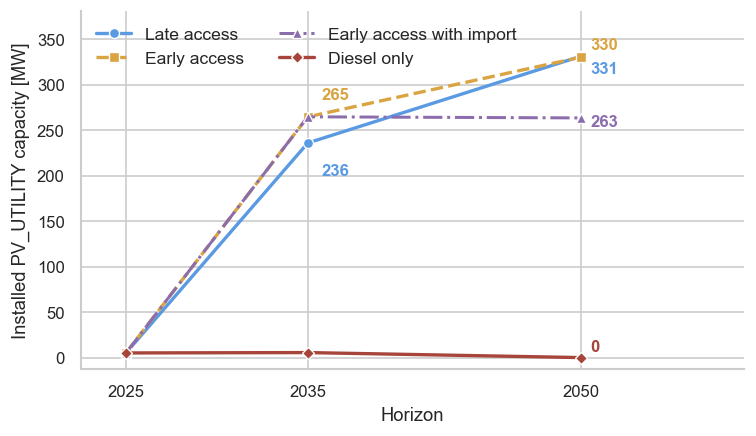

2050 PV_UTILITY: late 331.057 MW, early 330.055 MW - labelled 331 and 330


In [9]:
fig, ax = plt.subplots(figsize=(16.26 * CM, 9.5 * CM))

STYLE = {
    'Late access':   dict(marker='o', ls='-',  lw=2.0, ms=6),
    'Early access':  dict(marker='s', ls='--', lw=2.0, ms=5.5),
    'Early access\n+ Brazilian import': dict(marker='^', ls='-.', lw=1.8, ms=5.5),
    'No transition': dict(marker='D', ls='-',  lw=2.0, ms=5),
}
for lab in ['Late access', 'Early access', 'Early access\n+ Brazilian import', 'No transition']:
    ax.plot(PV_YEARS, pv.loc[lab, PV_YEARS].values, color=SCEN_COLORS[lab],
            label=DISPLAY[lab], markeredgecolor='white', markeredgewidth=0.8,
            zorder=3, **STYLE[lab])

# Value labels, each one in the colour of the series it belongs to.
ax.annotate(f"{pv.loc['Late access', 2035]:.0f}", (2035, pv.loc['Late access', 2035]),
            xytext=(8, -12), textcoords='offset points', ha='left', va='top', fontsize=10,
            fontweight='bold', color=SCEN_COLORS['Late access'])
ax.annotate(f"{pv.loc['Early access', 2035]:.0f}", (2035, pv.loc['Early access', 2035]),
            xytext=(8, 9), textcoords='offset points', ha='left', va='bottom', fontsize=10,
            fontweight='bold', color=SCEN_COLORS['Early access'])
BRAZIL = 'Early access\n+ Brazilian import'
ax.annotate(f'{pv.loc[BRAZIL, 2050]:.0f}', (2050, pv.loc[BRAZIL, 2050]), xytext=(6, -2),
            textcoords='offset points', ha='left', va='center', fontsize=10, fontweight='bold',
            color=SCEN_COLORS[BRAZIL])
ax.annotate(f"{pv.loc['No transition', 2050]:.0f}", (2050, pv.loc['No transition', 2050]),
            xytext=(6, 2), textcoords='offset points', ha='left', va='bottom', fontsize=10,
            fontweight='bold', color=SCEN_COLORS['No transition'])
# The two access calendars land on the same point at this scale. Each keeps its own
# value in its own colour rather than sharing one grey label read off neither series:
# the higher of the two above the marker, the lower below it. Ordering is derived from
# the values, so a rerun that swaps them swaps the labels too.
converged = pv.loc[['Late access', 'Early access'], 2050].sort_values(ascending=False)
for (lab, val), dy, va in zip(converged.items(), (-3, 3), ('top', 'bottom')):
    ax.annotate(f'{val:.0f}', (2050, val), xytext=(6, dy), textcoords='offset points',
                ha='left', va=va, fontsize=10, fontweight='bold', color=SCEN_COLORS[lab])
ax.set_xticks(PV_YEARS)
ax.set_xlim(2022.5, 2059)
ax.set_ylim(-12, pv.values.max() * 1.15)
ax.set_xlabel('Horizon', fontsize=11)
ax.set_ylabel('Installed PV_UTILITY capacity [MW]', fontsize=11)
ax.legend(loc='upper left', frameon=False, fontsize=10.5, ncol=2)

plt.tight_layout()
plt.show()
print(f"2050 PV_UTILITY: late {pv.loc['Late access', 2050]:.3f} MW, "
      f"early {pv.loc['Early access', 2050]:.3f} MW - labelled "
      f"{pv.loc['Late access', 2050]:.0f} and {pv.loc['Early access', 2050]:.0f}")

---
## 5. Cost and emission trajectories  [manuscript figure 28]

Both panels start from the same point. 2025 is the current system
(`norte_amazonia_reality_2025`), the installed fleet that every projection run is chained from,
so the three trajectories share one real anchor rather than a drawing convention.

* **Cost** is the reconstructed cost of Section 3, never the LP objective. At 2025 there is
  nothing to reconstruct - no tranche is chained into that horizon - so the reconstruction
  reduces to the sum of `Cost_breakdown.csv`, which is what is used.
* **Emissions** are `GWP_constr + GWP_op` summed over the five clusters, as
  `Gwp_breakdown.csv` reports them. `CO2_net` is a separate accounting column and is not added.
* **The import scenario is the one exception.** The greenhouse gas limit is not binding, so the
  emission factor of the import never entered the objective and the run carries the generic
  catalogue factor (`gwp_op_exterior` = 0.2065 ktCO2eq/GWh). Its emissions are recomputed here on
  the electricity actually imported, at the central factor 0.0385 ktCO2eq/GWh - the operational
  factor of the Brazilian interconnected system published for 2023.

Every value is checked against the published table before anything is drawn.

In [10]:
GWP_CENTRAL_IMPORT = 0.0385   # ktCO2eq/GWh, Brazilian interconnected system, operational, 2023.
                              # Not a model input: see the markdown above.
BRAZIL_CLUSTERS = ['C3', 'C5']          # the two clusters the interconnection reaches
ANCHOR_CASE = 'norte_amazonia_reality_2025'
BRAZIL_CASE = 'norte_amazonia_early_access_brazil_2050'
BRAZIL = 'Early access\n+ Brazilian import'
TRAJ_YEARS = [2025, 2035, 2050]
LINE_SCENARIOS = ['No transition', 'Late access', 'Early access']


def solve_ok(case_study):
    info = pd.read_csv(CS_ROOT / case_study / 'outputs' / 'Solve_info.csv', sep=r'\t;\t',
                       header=None, index_col=0, engine='python')
    return int(float(info.loc['solve_result_num', 1])) == 0


def gwp_total(case_study):
    """GWP_constr + GWP_op over the five clusters, in ktCO2eq/yr."""
    g = pd.read_csv(CS_ROOT / case_study / 'outputs' / 'Gwp_breakdown.csv',
                    sep=';', index_col=0).fillna(0.0)
    return float(g['GWP_constr'].sum() + g['GWP_op'].sum())


# 2025 anchor: the fleet the three trajectories leave from
assert solve_ok(ANCHOR_CASE), f'{ANCHOR_CASE}: non-optimal solve, refusing to use it as the anchor'
anchor_breakdown = pd.read_csv(CS_ROOT / ANCHOR_CASE / 'outputs' / 'Cost_breakdown.csv',
                               sep=';', index_col=0).fillna(0.0)
anchor_cost = float(anchor_breakdown[['C_inv', 'C_maint', 'C_op']].sum().sum())
anchor_gwp = gwp_total(ANCHOR_CASE)

# Import emissions, recomputed at the central factor.
# Imported electricity = what the two bordering clusters actually drew from outside.
br_res = pd.read_csv(CS_ROOT / BRAZIL_CASE / 'outputs' / 'regional_results' / 'Resources.csv', sep=';')
br_res.columns = [c.strip() for c in br_res.columns]
for c in ('Regions', 'Resources'):
    br_res[c] = br_res[c].astype(str).str.strip()
imported_gwh = float(pd.to_numeric(
    br_res.loc[(br_res['Resources'] == 'ELECTRICITY') & br_res['Regions'].isin(BRAZIL_CLUSTERS),
               'R_year_exterior'], errors='coerce').fillna(0.0).sum())

# The factor the run itself was solved with, read from the catalogue it was solved from.
res_indep = pd.read_csv(ES_ROOT / 'Data' / '2050' / 'early_access_brazil' / '00_INDEP' /
                        'Resources_indep.csv', sep=';', skiprows=[0, 1])
res_indep['parameter name'] = res_indep['parameter name'].astype(str).str.strip()
gwp_catalogue = float(res_indep.set_index('parameter name').loc['ELECTRICITY', 'gwp_op_exterior'])

gwp_brazil_raw = gwp_total(BRAZIL_CASE)
gwp_brazil_central = gwp_brazil_raw - imported_gwh * (gwp_catalogue - GWP_CENTRAL_IMPORT)

cost_by = {(r['label'], r['year']): r['reconstructed'] for _, r in costs.iterrows()}
gwp_by = {}
for label, year, key, case_study, _ in RUNS:
    gwp_by[(label, year)] = gwp_brazil_central if case_study == BRAZIL_CASE else gwp_total(case_study)
for label in LINE_SCENARIOS + [BRAZIL]:
    cost_by[(label, 2025)] = anchor_cost
    gwp_by[(label, 2025)] = anchor_gwp

traj = pd.DataFrame(
    [dict(label=lab, year=y, cost=cost_by[(lab, y)], gwp=gwp_by[(lab, y)])
     for lab in LINE_SCENARIOS for y in TRAJ_YEARS]
    + [dict(label=BRAZIL, year=2050, cost=cost_by[(BRAZIL, 2050)], gwp=gwp_by[(BRAZIL, 2050)])]
)

# Blocking check against the published table.
# Nothing below is a source of truth: every number above comes from the run outputs.
# These are the published figures the chapter text quotes, at the precision it quotes them.
EXPECTED_COST = {                                            # M-euro/yr, 2 decimals
    ('No transition', 2025): 66.51, ('Late access', 2025): 66.51, ('Early access', 2025): 66.51,
    ('No transition', 2035): 89.45, ('Late access', 2035): 44.06, ('Early access', 2035): 49.29,
    ('No transition', 2050): 123.41, ('Late access', 2050): 52.57, ('Early access', 2050): 52.96,
    (BRAZIL, 2050): 44.23,
}
EXPECTED_GWP = {                                             # ktCO2eq/yr, 1 decimal
    ('No transition', 2025): 217.7, ('Late access', 2025): 217.7, ('Early access', 2025): 217.7,
    ('No transition', 2035): 286.8, ('Late access', 2035): 76.7, ('Early access', 2035): 81.1,
    ('No transition', 2050): 380.7, ('Late access', 2050): 89.0, ('Early access', 2050): 89.1,
    (BRAZIL, 2050): 81.3,
}

failures = []
for _, r in traj.iterrows():
    k = (r['label'], r['year'])
    if f"{r['cost']:.2f}" != f"{EXPECTED_COST[k]:.2f}":
        failures.append(f"cost {DISPLAY[r['label']]} {r['year']}: "
                        f"computed {r['cost']:.4f}, published {EXPECTED_COST[k]:.2f}")
    if f"{r['gwp']:.1f}" != f"{EXPECTED_GWP[k]:.1f}":
        failures.append(f"emissions {DISPLAY[r['label']]} {r['year']}: "
                        f"computed {r['gwp']:.4f}, published {EXPECTED_GWP[k]:.1f}")
assert not failures, 'trajectory values do not match the published table:\n  ' + '\n  '.join(failures)

print(f'All {2 * len(traj)} plotted values match the published table at its own precision.\n')
print(f'2025 anchor  : {ANCHOR_CASE}')
print(f'               {anchor_cost:.4f} M-euro/yr, {anchor_gwp:.4f} ktCO2eq/yr'
      f'  - shared by the three trajectories')
print(f'import       : {imported_gwh:.4f} GWh/yr drawn by {" + ".join(BRAZIL_CLUSTERS)}, '
      f'solved at {gwp_catalogue:.6f} ktCO2eq/GWh')
print(f'               {gwp_brazil_raw:.4f} ktCO2eq/yr as solved -> {gwp_brazil_central:.4f} '
      f'at the central factor {GWP_CENTRAL_IMPORT}\n')
print(traj.assign(label=lambda d: d['label'].map(DISPLAY)).round(4).to_string(index=False))


All 20 plotted values match the published table at its own precision.

2025 anchor  : norte_amazonia_reality_2025
               66.5105 M-euro/yr, 217.6686 ktCO2eq/yr  - shared by the three trajectories
import       : 113.8000 GWh/yr drawn by C3 + C5, solved at 0.206486 ktCO2eq/GWh
               100.4603 ktCO2eq/yr as solved -> 81.3435 at the central factor 0.0385

                   label  year     cost      gwp
             Diesel only  2025  66.5105 217.6686
             Diesel only  2035  89.4507 286.7837
             Diesel only  2050 123.4106 380.7024
             Late access  2025  66.5105 217.6686
             Late access  2035  44.0582  76.6973
             Late access  2050  52.5660  89.0061
            Early access  2025  66.5105 217.6686
            Early access  2035  49.2900  81.1206
            Early access  2050  52.9623  89.1408
Early access with import  2050  44.2263  81.3435


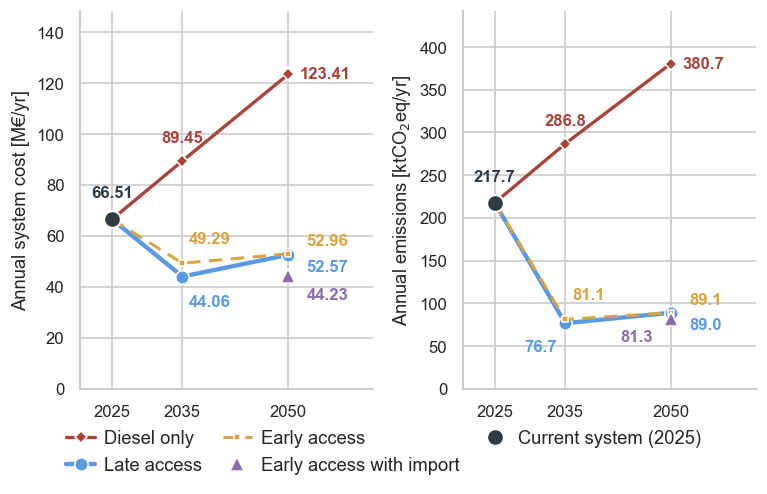

2050 cost      : late 52.566 vs early 52.962 M-euro/yr (+0.396)
2050 emissions : late 89.006 vs early 89.141 ktCO2eq/yr (+0.135)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16.5 * CM, 9.4 * CM))

ANCHOR_COLOR = '#2F3B45'
# Late access is the reference path, drawn solid and thick; early access is drawn dashed
# on top of it in its own colour, so that where the two coincide at 2050 the gaps in the
# dashes keep both visible. Their markers differ in size for the same reason: the smaller
# square sits inside the larger circle instead of hiding it.
TRAJ_STYLE = {
    'No transition': dict(ls='-', lw=2.0, marker='D', ms=5.5),
    'Late access':   dict(ls='-', lw=2.6, marker='o', ms=8.0),
    'Early access':  dict(ls=(0, (4.5, 2.8)), lw=1.8, marker='s', ms=4.0),
}
# Per-panel annotation geometry. The import sits 9.97 M-euro below the 2050 pair in the
# cost panel but only 10.97 ktCO2eq below it in the emissions panel, which on a 0-based
# linear axis is four times closer, so its label cannot go on the same side in both.
PANELS = [
    dict(col='cost', ylabel='Annual system cost [M\u20ac/yr]',
         fmt='{:.2f}', headroom=1.20,
         nt35=(0, 9, 'center', 'bottom'), nt50=(7, 0, 'left', 'center'),
         late35=(4, -11, 'left', 'top'), early35=(4, 10, 'left', 'bottom'),
         imp=(11, -7, 'left', 'top')),
    dict(col='gwp', ylabel='Annual emissions [ktCO$_2$eq/yr]',
         fmt='{:.1f}', headroom=1.16,
         nt35=(0, 9, 'center', 'bottom'), nt50=(7, 0, 'left', 'center'),
         late35=(-5, -10, 'right', 'top'), early35=(4, 10, 'left', 'bottom'),
         imp=(-11, -6, 'right', 'top')),
]

for ax, P in zip(axes, PANELS):
    col, fmt = P['col'], P['fmt']
    series = {lab: traj[traj['label'] == lab].set_index('year')[col] for lab in LINE_SCENARIOS}

    for lab in LINE_SCENARIOS:
        ax.plot(TRAJ_YEARS, [series[lab][y] for y in TRAJ_YEARS], color=SCEN_COLORS[lab],
                label=DISPLAY[lab], markeredgecolor='white', markeredgewidth=0.9,
                zorder=3, **TRAJ_STYLE[lab])

    # The import: a single point at 2050, no trajectory - the scenario has no 2035 run of
    # its own. The dotted drop-line is not a path, it is the vertical distance to the
    # early-access point the marker is read against.
    import_val = float(traj.loc[(traj['label'] == BRAZIL) & (traj['year'] == 2050), col].iloc[0])
    ax.plot([2050, 2050], [series['Early access'][2050], import_val], color=NEUTRAL,
            lw=0.9, ls=':', zorder=2)
    ax.plot([2050], [import_val], marker='^', ms=8.5, color=SCEN_COLORS[BRAZIL],
            markeredgecolor='white', markeredgewidth=0.9, ls='none', zorder=4,
            label=DISPLAY[BRAZIL])

    # The 2025 anchor: one marker, drawn once, on top of the three lines that leave it.
    ax.plot([2025], [series['Late access'][2025]], marker='o', ms=10, color=ANCHOR_COLOR,
            markeredgecolor='white', markeredgewidth=1.2, ls='none', zorder=5,
            label=ANCHOR_LABEL)

    ax.set_ylim(0, max(series[lab].max() for lab in LINE_SCENARIOS) * P['headroom'])
    ax.set_xlim(2020.5, 2062)
    ax.set_xticks(TRAJ_YEARS)
    ax.set_ylabel(P['ylabel'], fontsize=11)

    def tag(text, xy, spec, color):
        dx, dy, ha, va = spec
        ax.annotate(text, xy, xytext=(dx, dy), textcoords='offset points', ha=ha, va=va,
                    fontsize=10, fontweight='bold', color=color, zorder=6)

    tag(fmt.format(series['Late access'][2025]), (2025, series['Late access'][2025]),
        (0, 11, 'center', 'bottom'), ANCHOR_COLOR)
    tag(fmt.format(series['No transition'][2035]), (2035, series['No transition'][2035]),
        P['nt35'], SCEN_COLORS['No transition'])
    tag(fmt.format(series['No transition'][2050]), (2050, series['No transition'][2050]),
        P['nt50'], SCEN_COLORS['No transition'])
    tag(fmt.format(series['Late access'][2035]), (2035, series['Late access'][2035]),
        P['late35'], SCEN_COLORS['Late access'])
    tag(fmt.format(series['Early access'][2035]), (2035, series['Early access'][2035]),
        P['early35'], SCEN_COLORS['Early access'])
    tag(fmt.format(import_val), (2050, import_val), P['imp'], SCEN_COLORS[BRAZIL])

    # The 2050 convergence, written out rather than left to the eye.
    # The two access calendars land on top of each other. Each value is drawn in its own
    # series colour instead of in one grey block, the higher above the marker and the
    # lower below it, so neither can be mistaken for the other one hidden underneath.
    # The ordering is read off the values, and it differs between the two panels.
    # The reading of that convergence is caption material, so nothing is written on the
    # figure beyond the two numbers themselves.
    pair = sorted((('Late access', series['Late access'][2050]),
                   ('Early access', series['Early access'][2050])),
                  key=lambda kv: kv[1], reverse=True)
    for (lab, val), spec in zip(pair, ((11, 3, 'left', 'bottom'), (11, -3, 'left', 'top'))):
        tag(fmt.format(val), (2050, val), spec, SCEN_COLORS[lab])

handles, labels = axes[0].get_legend_handles_labels()
order = [labels.index(DISPLAY[l]) for l in LINE_SCENARIOS] + \
        [labels.index(DISPLAY[BRAZIL]), labels.index(ANCHOR_LABEL)]
# The five-entry legend row is the widest artist on this figure, so it, not the axes,
# sets the exported width. Its handles and gaps are tightened to fit the 16 cm target;
# the entries and their order are unchanged.
fig.legend([handles[i] for i in order], [labels[i] for i in order],
           loc='lower center', bbox_to_anchor=(0.5, -0.10), fontsize=11, ncol=3, frameon=False,
           handlelength=1.6, handletextpad=0.5, columnspacing=1.1,
           borderaxespad=0.0)

plt.tight_layout()
plt.show()

d50 = traj[traj['year'] == 2050].set_index('label')
print(f"2050 cost      : late {d50.loc['Late access', 'cost']:.3f} vs early "
      f"{d50.loc['Early access', 'cost']:.3f} M-euro/yr "
      f"({d50.loc['Early access', 'cost'] - d50.loc['Late access', 'cost']:+.3f})")
print(f"2050 emissions : late {d50.loc['Late access', 'gwp']:.3f} vs early "
      f"{d50.loc['Early access', 'gwp']:.3f} ktCO2eq/yr "
      f"({d50.loc['Early access', 'gwp'] - d50.loc['Late access', 'gwp']:+.3f})")


---
## Key figures, for cross-checking against the chapter text

In [12]:
print('FIGURE 1 - demography')
print(f'  population 2024 -> 2050 : {pop_series[2024]:,.0f} -> {pop_series[2050]:,.0f}'
      f'   index {pop_index[2050]:.1f}  ({pop_index[2050] - 100:+.1f} %)')
print(f'  households 2024 -> 2050 : {hh_series[2024]:,.0f} -> {hh_series[2050]:,.0f}'
      f'   index {hh_index[2050]:.1f}  ({hh_index[2050] - 100:+.1f} %)')
print(f'  at 2035                 : population {pop_index[2035]:.1f}, households {hh_index[2035]:.1f}')
print(f'  household size          : {pop_series[2024]/hh_series[2024]:.3f} -> '
      f'{pop_series[2035]/hh_series[2035]:.3f} -> {pop_series[2050]/hh_series[2050]:.3f}')

print('\nFIGURE 2 - access rate [%]')
print(pd.DataFrame({lab.replace('\n', ' '): vals for lab, vals, _, _ in BARS}, index=GROUPS).round(2).to_string())

print('\nFIGURE 3 - reconstructed annual cost [M-euro/yr]')
print(costs.assign(label=lambda d: d['label'].str.replace('\n', ' '))[
    ['year', 'label', 'C_inv_lp', 'adjustment', 'C_maint', 'C_op', 'reconstructed', 'lp_raw']
].round(3).to_string(index=False))

print('\nFIGURE 4 - regional PV_UTILITY capacity [MW]')
print(pv.rename(index=lambda s: s.replace('\n', ' ')).round(3).to_string())
print('\nFIGURE 5 - trajectories from the 2025 anchor')
print(traj.assign(label=lambda d: d['label'].map(DISPLAY))
      .pivot(index='year', columns='label', values=['cost', 'gwp']).round(3).to_string())
print(f'  2025 anchor shared by the three trajectories : {anchor_cost:.2f} M-euro/yr, '
      f'{anchor_gwp:.1f} ktCO2eq/yr')
print(f'  import emissions at {GWP_CENTRAL_IMPORT} ktCO2eq/GWh on {imported_gwh:.1f} GWh/yr : '
      f'{gwp_brazil_central:.1f} ktCO2eq/yr (solved value {gwp_brazil_raw:.1f})')


FIGURE 1 - demography
  population 2024 -> 2050 : 317,517 -> 381,165   index 120.0  (+20.0 %)
  households 2024 -> 2050 : 84,209 -> 120,199   index 142.7  (+42.7 %)
  at 2035                 : population 110.1, households 120.9
  household size          : 3.771 -> 3.434 -> 3.171

FIGURE 2 - access rate [%]
        2024 observed  2035 access in 2035  2035 access in 2050  2050 both trajectories
C1              77.74                100.0                89.03                   100.0
C2              68.45                100.0                86.56                   100.0
C3              89.83                100.0                94.83                   100.0
C4              74.66                100.0                89.43                   100.0
C5              97.46                100.0                99.28                   100.0
Region          86.48                100.0                93.74                   100.0

FIGURE 3 - reconstructed annual cost [M-euro/yr]
 year                     